<Strong><span style="font-size:40px;color:lightgreen">Crypto index fund model</strong>

<span style="color:orange;font-size:30px">Imports

In [38]:
print("Starting Imports...")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import datetime
import os
import yfinance as yf
import logging
print("Imports completed.")

train = False  # Set to True to train the model, False to just run the environment
training_cut_off = datetime.datetime(2025, 1, 1) # Date to split training and testing data

Starting Imports...
Imports completed.


<Strong><span style="color:orange;font-size:30px">Environment<br></strong>
see 'Python-Projects/quant ml/crypto model build/crypto_env.py'


<span style="color:green;font-size:25px">Data formatting from yfinance

In [39]:
def rolling_statistics(df, target_col, group_col, window):
    """
    df: Pandas DataFrame
    target_col: string, name of the column to calculate rolling stats on
    group_col: string, name of the grouping column
    window: int, window size
    """
    rolling_max = df.groupby(group_col)[target_col].rolling(window=window).max().reset_index(level=0, drop=True)
    rolling_min = df.groupby(group_col)[target_col].rolling(window=window).min().reset_index(level=0, drop=True)
    rolling_std = df.groupby(group_col)[target_col].rolling(window=window).std().reset_index(level=0, drop=True)
    rolling_avg = df.groupby(group_col)[target_col].rolling(window=window).mean().reset_index(level=0, drop=True)
    return rolling_max, rolling_min, rolling_std, rolling_avg

def rsi (df, target_col, group_col, window):
    """
    calcualtes the RSI score (Relative Strength Index) for a given data series
    :paramaters
        data: pandas Series
        Window: int, length of rolling window
    """
    delta = df.groupby(group_col)[target_col].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.groupby(df[group_col]).rolling(window=window).mean().reset_index(level=0, drop=True)
    avg_loss = loss.groupby(df[group_col]).rolling(window=window).mean().reset_index(level=0, drop=True)
    rs = avg_gain / (avg_loss + 1e-10)
    rsi = 100 - (100 / (1 + rs))
    return rsi

def macd(df, target_col, short_window, long_window, signal_window, group_col):
    """
    Moving Average Convergence Divergence (MACD) calculation.
    Measures trend strength and direction.
    Parameters:
        df: Pandas DataFrame
        target_col: str, column name to compute MACD on
        short_window: int, short-term EMA window (default 12)
        long_window: int, long-term EMA window (default 26)
        signal_window: int, signal line EMA window (default 9)
        group_col: str, column name to group by (e.g., 'Ticker')
    Returns:
        macd_line: Pandas Series aligned with df.index
        macd_signal: Pandas Series aligned with df.index
    """
    ema_short = df.groupby(group_col)[target_col].transform(lambda x: x.ewm(span=short_window, adjust=False).mean())
    ema_long = df.groupby(group_col)[target_col].transform(lambda x: x.ewm(span=long_window, adjust=False).mean())
    macd_line = ema_short - ema_long

    # Calculate signal line by applying ewm *per group* but keep original index using transform
    macd_signal = macd_line.groupby(df[group_col]).transform(lambda x: x.ewm(span=signal_window, adjust=False).mean())
    return macd_line.astype(np.float32), macd_signal.astype(np.float32)



data colection and feature enginnering 

In [40]:
tickers = ['BTC-USD', 'ETH-USD', 'XRP-USD', 'LTC-USD', 'BCH-USD']

yfinance_data = pd.DataFrame()

print(f"Downloading data from Yahoo Finance...")
try:
    ticker_data = yf.download(tickers, start="2019-01-01", end=datetime.datetime.now().strftime("%Y-%m-%d"))
    print(f"Data download completed.")
except Exception as e:
    logging.error(f"Error downloading data.")
    raise

print(f"unmprocessed ticker data")
print(ticker_data.head())

ticker_data = ticker_data.stack(level=1).reset_index()
# Rename columns to something clearer
ticker_data.columns = ['Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume']
# Optional: sort for neatness
ticker_data = ticker_data.sort_values(['Date', 'Ticker'], ascending=[True,True]).reset_index(drop=True)
print("corrected ticker cols and index")
print(ticker_data.head())

feature_cols_to_engineer = ['Close']
# Add engineered features
for col in feature_cols_to_engineer:
    ticker_data[f'{col}_rolling_max'], ticker_data[f'{col}_rolling_min'], ticker_data[f'{col}_rolling_std'], ticker_data[f'{col}_rolling_avg'] = rolling_statistics(ticker_data, col, 'Ticker', window=14)
    ticker_data[f'{col}_rsi'] = rsi(ticker_data, col, 'Ticker', window=14)
    macd_line, macd_signal = macd(ticker_data, col, 12, 26, 9, 'Ticker')
    ticker_data[f'{col}_macd_line'] = macd_line
    ticker_data[f'{col}_macd_signal'] = macd_signal
print("fully processed ticker data with feature engineering")
print(ticker_data.head())
print(ticker_data.tail())

[*********************100%***********************]  5 of 5 completed

Data download completed.
unmprocessed ticker data
Price            Close                                                \
Ticker         BCH-USD      BTC-USD     ETH-USD    LTC-USD   XRP-USD   
Date                                                                   
2019-01-01  164.854599  3843.520020  140.819412  31.979931  0.364771   
2019-01-02  171.827377  3943.409424  155.047684  33.433681  0.375243   
2019-01-03  162.049927  3836.741211  149.135010  32.026699  0.360224   
2019-01-04  161.395630  3857.717529  154.581940  32.404167  0.356747   
2019-01-05  160.401215  3845.194580  155.638596  34.936867  0.355275   

Price             High                                                ...  \
Ticker         BCH-USD      BTC-USD     ETH-USD    LTC-USD   XRP-USD  ...   
Date                                                                  ...   
2019-01-01  168.768265  3850.913818  141.397507  32.097584  0.364771  ...   
2019-01-02  174.233536  3947.981201  156.929138  33.793324  0.378


/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_24827/334704622.py:16: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  ticker_data = ticker_data.stack(level=1).reset_index()


- training loop bulid <br>
- training chart <br>
- Logging of model activities <br>
- Model Storage

In [41]:
# train test split on date

df_train = ticker_data[ticker_data['Date'] < training_cut_off].reset_index(drop=True)
df_test = ticker_data[ticker_data['Date'] >= training_cut_off].reset_index(drop=True)
print(f"Training data from {df_train['Date'].min()} to {df_train['Date'].max()}, {len(df_train)} rows")
print(f"testing data from {df_test['Date'].min()} to {df_test['Date'].max()}, {len(df_test)} rows")

display(df_train.info())
display(df_test.info())

Training data from 2019-01-01 00:00:00 to 2024-12-31 00:00:00, 10960 rows
testing data from 2025-01-01 00:00:00 to 2026-02-02 00:00:00, 1990 rows
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10960 entries, 0 to 10959
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               10960 non-null  datetime64[ns]
 1   Ticker             10960 non-null  object        
 2   Open               10960 non-null  float64       
 3   High               10960 non-null  float64       
 4   Low                10960 non-null  float64       
 5   Close              10960 non-null  float64       
 6   Volume             10960 non-null  int64         
 7   Close_rolling_max  10895 non-null  float64       
 8   Close_rolling_min  10895 non-null  float64       
 9   Close_rolling_std  10895 non-null  float64       
 10  Close_rolling_avg  10895 non-null  float64       
 11  Close_rsi          10895 

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1990 entries, 0 to 1989
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               1990 non-null   datetime64[ns]
 1   Ticker             1990 non-null   object        
 2   Open               1990 non-null   float64       
 3   High               1990 non-null   float64       
 4   Low                1990 non-null   float64       
 5   Close              1990 non-null   float64       
 6   Volume             1990 non-null   int64         
 7   Close_rolling_max  1990 non-null   float64       
 8   Close_rolling_min  1990 non-null   float64       
 9   Close_rolling_std  1990 non-null   float64       
 10  Close_rolling_avg  1990 non-null   float64       
 11  Close_rsi          1990 non-null   float64       
 12  Close_macd_line    1990 non-null   float32       
 13  Close_macd_signal  1990 non-null   float32       
dtypes: datet

None

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import stable_baselines3 as sb3
import csv
import sys
from itertools import product
import random
import glob
from datetime import datetime

sys.path.append('/Users/zacwells/Documents/Python-Projects/quant ml/crypto model build/crypto_env.py')
from crypto_env import CryptoIndexFundTradingEnv
from stable_baselines3.common.callbacks import EvalCallback

train_env = CryptoIndexFundTradingEnv(
    data=df_train,
    transaction_cost=0.002,
    initial_cash=10000.0
)
train_env.reward_mode = "mixed"

test_env = CryptoIndexFundTradingEnv(
    data=df_test,
    transaction_cost=0.002,
    initial_cash=10000.0
)

# ================================================================
# TIMESTAMP UTILITY
# ================================================================
def timestamp():
    return datetime.now().strftime("%Y%m%d_%H%M%S")


# ================================================================
# 1. ANALYSIS FUNCTION
# ================================================================
RISK_FREE_RATE = 0.02

def analyze_portfolio_performance(test_env, model):
    obs, _ = test_env.reset()
    done = False
    
    portfolio_values, benchmark_values, asset_allocations = [], [], []
    initial_portfolio_value = test_env.initial_cash
    
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = test_env.step(action)
        done = terminated or truncated
        
        portfolio_values.append(info['portfolio_value'])
        benchmark_values.append(info['market_value'])
        current_allocation = np.concatenate([[info['cash']], info['asset_values']])
        asset_allocations.append(current_allocation)

    portfolio_values = np.array(portfolio_values)
    benchmark_values = np.array(benchmark_values)
    asset_allocations = np.array(asset_allocations)
    
    portfolio_returns_pct = (portfolio_values[-1] - initial_portfolio_value) / initial_portfolio_value
    benchmark_returns_pct = (benchmark_values[-1] - benchmark_values[0]) / benchmark_values[0]
    
    daily_returns = np.diff(portfolio_values) / portfolio_values[:-1]
    sharpe_ratio = (np.mean(daily_returns) * 252 - RISK_FREE_RATE) / (np.std(daily_returns) * np.sqrt(252))
    max_drawdown = np.min(portfolio_values / np.maximum.accumulate(portfolio_values) - 1)

    metrics = {
        'final_value': portfolio_values[-1],
        'total_return_pct': portfolio_returns_pct * 100,
        'market_return_pct': benchmark_returns_pct * 100,
        'outperformance_pct': (portfolio_returns_pct - benchmark_returns_pct) * 100,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown_pct': max_drawdown * 100
    }
    return metrics, portfolio_values, benchmark_values, asset_allocations


# ================================================================
# 2. TRAIN + EVAL
# ================================================================
def train_and_evaluate(hparams, train_env, test_env, total_timesteps=500_000):
    model = sb3.PPO('MlpPolicy', train_env, **hparams, verbose=0)

    eval_callback = EvalCallback(
        test_env,
        best_model_save_path=f"./tmp_best_model_{timestamp()}/",
        log_path=None,
        eval_freq=10_000,
        deterministic=True,
        render=False
    )

    model.learn(total_timesteps=total_timesteps, callback=eval_callback)
    metrics, _, _, _ = analyze_portfolio_performance(test_env, model)
    return metrics


# ================================================================
# 3. RANDOMIZED SEARCH (SAFE)
# ================================================================
CSV_FILE = "hyperparam_search_results.csv"
SAMPLED_GRID_FILE = "sampled_grid.csv"

def randomized_search_cv_from_grid(search_space, n_samples, seed=42, total_timesteps=250_000):

    random.seed(seed)

    keys = list(search_space.keys())
    all_combos = list(product(*[search_space[k] for k in keys]))
    total_combos = len(all_combos)
    print(f"Total combos in grid: {total_combos}")

    if n_samples > total_combos:
        raise ValueError(f"n_samples ({n_samples}) > total combos ({total_combos}).")

    sampled_indices = random.sample(range(total_combos), n_samples)
    sampled_combos = [all_combos[i] for i in sampled_indices]

    # Save sampled combos
    with open(SAMPLED_GRID_FILE, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(keys)
        for combo in sampled_combos:
            writer.writerow(combo)

    # Write CSV header
    with open(CSV_FILE, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(keys + [
            "final_value", "total_return_pct", "market_return_pct",
            "outperformance_pct", "sharpe_ratio", "max_drawdown_pct"
        ])

    results = []
    for i, combo in enumerate(sampled_combos, 1):
        hparams = dict(zip(keys, combo))
        print(f"\n🎲 RandomSearchCV [{i}/{n_samples}] - {hparams}")

        metrics = train_and_evaluate(hparams, train_env, test_env, total_timesteps=total_timesteps)
        results.append((hparams, metrics))

        print(f"➡️ Return: {metrics['total_return_pct']:.2f}%, Sharpe: {metrics['sharpe_ratio']:.2f}")

        with open(CSV_FILE, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([hparams[k] for k in keys] + [
                metrics['final_value'],
                metrics['total_return_pct'],
                metrics['market_return_pct'],
                metrics['outperformance_pct'],
                metrics['sharpe_ratio'],
                metrics['max_drawdown_pct']
            ])
    return results


# ================================================================
# 4. MAIN EXECUTION CONTROLLER (WITH SAFE SAVES)
# ================================================================
def main(train=train):

    # Build environments
    train_env = CryptoIndexFundTradingEnv(
        data=df_train,
        transaction_cost=0.002,
        initial_cash=10000.0
    )
    train_env.reward_mode = "mixed"

    test_env = CryptoIndexFundTradingEnv(
        data=df_test,
        transaction_cost=0.002,
        initial_cash=10000.0
    )

    if train == True:

        search_space = {
            "learning_rate": [ 1e-3], # [1e-5, 5e-5, 1e-4,],      # LR stays — small set, big effect
            "n_steps": [2048],                    # Cut 2048 for speed
            "batch_size": [256],                   # Cut 32 and 256, both extremes
            "gamma": [0.95, 0.99],                     # Two flavours: normal + long memory
            "gae_lambda": [0.90, 0.95],                # Reasonable range without bloat
            "clip_range": [0.1, 0.2, 1],                  # Cut 0.3 — rarely optimal unless reward is chaotic
            "ent_coef": [0.0, 0.01, 0.1],                   # Small entropy, nothing exotic
        }

        total_grid = 1 * 1 * 1 * 2 * 2 * 3 * 3
        n_samples = int(total_grid * 0.5)

        results = randomized_search_cv_from_grid(
            search_space,
            n_samples=n_samples,
            seed=123,
            total_timesteps=250_000
        )

        best = max(results, key=lambda x: x[1]['sharpe_ratio'])
        best_hparams = best[0]

        print("🏆 Best Hyperparameters Found:")
        print(best_hparams)

        # ====================================================
        # FULL TRAINING WITH SAFE SAVES
        # ====================================================
        model = sb3.PPO(
            'MlpPolicy',
            train_env,
            **best_hparams,
            verbose=1,
            tensorboard_log=f"./tensorboard_{timestamp()}/"
        )

        eval_callback = EvalCallback(
            test_env,
            best_model_save_path=f"./best_model_{timestamp()}/",
            log_path=f"./logs_{timestamp()}/",
            eval_freq=10_000,
            deterministic=True,
            render=False
        )

        total_steps = 2_000_000
        print(f"🚀 Final Training Started for {total_steps:,} steps")

        model.learn(
            total_timesteps=total_steps,
            callback=eval_callback,
            reset_num_timesteps=False
        )

        # SAFE SAVE
        final_name = f"final_crypto_model_{timestamp()}.zip"
        model.save(final_name)
        print(f"💾 Final model saved as: {final_name}")

    else:
        # Load latest model safely
        models = sorted(glob.glob("final_crypto_model_*.zip"))
        if not models:
            raise RuntimeError("No saved models found!")
        latest = models[-1]
        print(f"📂 Loading latest model: {latest}")
        model = sb3.PPO.load(latest)

        metrics, pv, bv, alloc = analyze_portfolio_performance(test_env, model)
        print("Evaluation metrics:", metrics)


# ================================================================
# RUN
# ================================================================
if __name__ == "__main__":
    main(train=train)

📂 Loading latest model: final_crypto_model_20251123_090826.zip
Evaluation metrics: {'final_value': np.float64(7269.025195414137), 'total_return_pct': np.float64(-27.309748045858633), 'market_return_pct': np.float32(-22.371382), 'outperformance_pct': np.float64(-4.9383665246336585), 'sharpe_ratio': np.float64(-0.12311737654521883), 'max_drawdown_pct': np.float64(-50.76383017162214)}


In [43]:
import glob
import stable_baselines3 as sb3

def find_best_saved_model():
    best_metric = -float("inf")
    best_model = None
    best_path = None

    for path in glob.glob("best_model_*/best_model.zip"):
        model = sb3.PPO.load(path)
        metrics, _, _, _ = analyze_portfolio_performance(test_env, model)
        
        if metrics["sharpe_ratio"] > best_metric:
            best_metric = metrics["sharpe_ratio"]
            best_model = model
            best_path = path

    print("Best model:", best_path)
    print("Best Sharpe:", best_metric)
    return best_model, best_path

best_model, best_path = find_best_saved_model()

Best model: best_model_20251123_090325/best_model.zip
Best Sharpe: -0.1257555128743468


- Testing loop build<br>
- Testing performance - portfolio growth<br>
- actions <br>
- Risk appitite analysis <br>


=== Final Best Crypto Model Performance Summary ===
Final Portfolio Value: $7,326.97
Total Return: -26.73%
Market Return: -22.37%
Outperformance: -4.36%
Sharpe Ratio: -0.13
Max Drawdown: -50.13%

=== Final Best General Model Performance Summary ===
Final Portfolio Value: $8,733.79
Total Return: -12.66%
Market Return: -22.37%
Outperformance: 9.71%
Sharpe Ratio: 0.03
Max Drawdown: -41.01%

=== Final Best Crypto Model Performance Summary ===
Final Portfolio Value: $8,202.07
Total Return: -17.98%
Market Return: -22.37%
Outperformance: 4.39%
Sharpe Ratio: -0.05
Max Drawdown: -45.80%


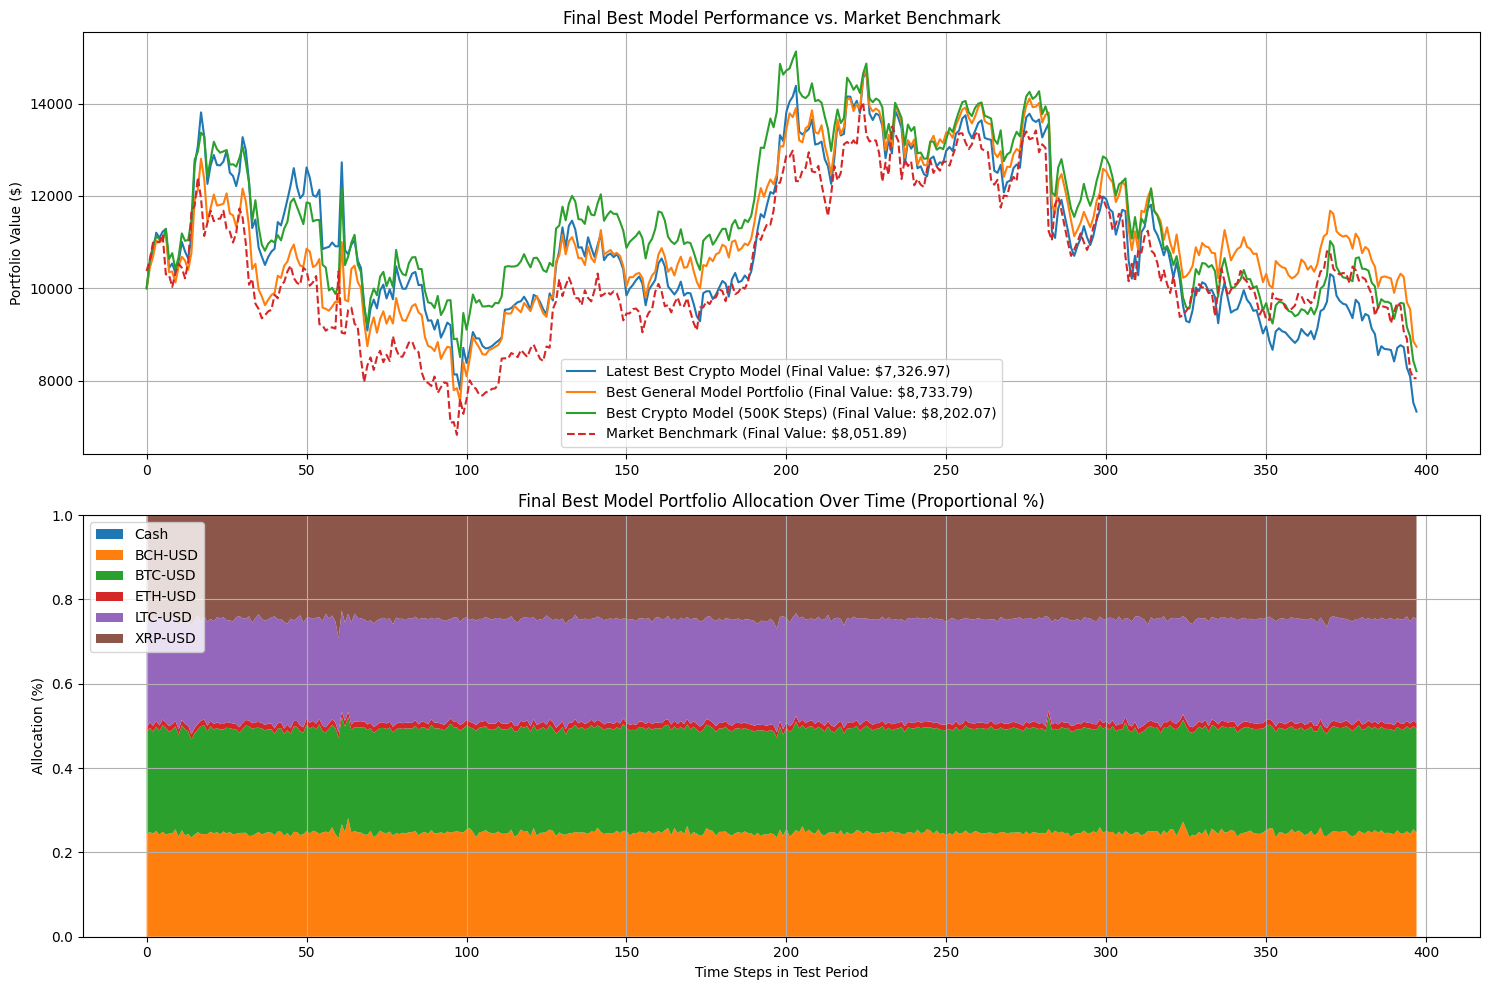

In [46]:
import stable_baselines3 as sb3

latest_model = sb3.PPO.load(best_path)
latest_model_metrics, latest_pv, latest_bv, latest_alloc = analyze_portfolio_performance(test_env, latest_model)

print("\n=== Final Best Crypto Model Performance Summary ===")
print(f"Final Portfolio Value: ${latest_model_metrics['final_value']:,.2f}")
print(f"Total Return: {latest_model_metrics['total_return_pct']:.2f}%")
print(f"Market Return: {latest_model_metrics['market_return_pct']:.2f}%")
print(f"Outperformance: {latest_model_metrics['outperformance_pct']:.2f}%")
print(f"Sharpe Ratio: {latest_model_metrics['sharpe_ratio']:.2f}")
print(f"Max Drawdown: {latest_model_metrics['max_drawdown_pct']:.2f}%")

best_model = sb3.PPO.load("./best_model/best_model.zip")
final_metrics, final_pv, final_bv, final_alloc = analyze_portfolio_performance(test_env, best_model)

print("\n=== Final Best General Model Performance Summary ===")
print(f"Final Portfolio Value: ${final_metrics['final_value']:,.2f}")
print(f"Total Return: {final_metrics['total_return_pct']:.2f}%")
print(f"Market Return: {final_metrics['market_return_pct']:.2f}%")
print(f"Outperformance: {final_metrics['outperformance_pct']:.2f}%")
print(f"Sharpe Ratio: {final_metrics['sharpe_ratio']:.2f}")
print(f"Max Drawdown: {final_metrics['max_drawdown_pct']:.2f}%")

crypto_fund_model = sb3.PPO.load("/Users/zacwells/Documents/Python-Projects/quant ml/crypto model build/crypto_index_fund_ppo_500000.zip")
final_metrics_crypto, final_pv_crypto, final_bv_crypto, final_alloc_crypto = analyze_portfolio_performance(test_env, crypto_fund_model)

print("\n=== Final Best Crypto Model Performance Summary ===")
print(f"Final Portfolio Value: ${final_metrics_crypto['final_value']:,.2f}")
print(f"Total Return: {final_metrics_crypto['total_return_pct']:.2f}%")
print(f"Market Return: {final_metrics_crypto['market_return_pct']:.2f}%")
print(f"Outperformance: {final_metrics_crypto['outperformance_pct']:.2f}%")
print(f"Sharpe Ratio: {final_metrics_crypto['sharpe_ratio']:.2f}")
print(f"Max Drawdown: {final_metrics_crypto['max_drawdown_pct']:.2f}%")

plt.figure(figsize=(15, 10))

# =========================================================
# 1. TOP PLOT — Portfolio Value vs Benchmark
# =========================================================
ax1 = plt.subplot(2, 1, 1)
ax1.plot(latest_pv, 
         label=f"Latest Best Crypto Model (Final Value: ${latest_pv[-1]:,.2f})")
ax1.plot(final_pv, 
         label=f"Best General Model Portfolio (Final Value: ${final_pv[-1]:,.2f})")
ax1.plot(final_pv_crypto, 
         label=f"Best Crypto Model (500K Steps) (Final Value: ${final_pv_crypto[-1]:,.2f})")
ax1.plot(final_bv,
         label=f"Market Benchmark (Final Value: ${final_bv[-1]:,.2f})",
         linestyle='--')
ax1.set_title("Final Best Model Performance vs. Market Benchmark")
ax1.set_ylabel("Portfolio Value ($)")
ax1.legend()
ax1.grid(True)


# =========================================================
# 2. BOTTOM PLOT — Proportional Allocation (0–100%)
# =========================================================

# Convert allocation values -> percentages of total portfolio
alloc = np.array(final_alloc)          # shape: (T, assets+cash)
alloc_pct = alloc / alloc.sum(axis=1, keepdims=True)
alloc_T_pct = alloc_pct.T
labels = ['Cash'] + test_env.tickers
ax2 = plt.subplot(2, 1, 2)
ax2.stackplot(
    np.arange(len(final_pv)),
    alloc_T_pct,
    labels=labels,
    alpha=1
)
ax2.set_title("Final Best Model Portfolio Allocation Over Time (Proportional %)")
ax2.set_ylabel("Allocation (%)")
ax2.set_xlabel("Time Steps in Test Period")
ax2.set_ylim(0, 1)       # Makes it a clean 0–100% stackplot
ax2.legend(loc='upper left')
ax2.grid(True)

plt.tight_layout()
plt.show()

print()

In [45]:
allocation_df = pd.DataFrame(final_alloc, columns=['Cash'] + test_env.tickers)
print(allocation_df.info())

percentage_cols = [col for col in allocation_df.columns if col != 'Cash']

for col in percentage_cols:
    allocation_df[col+'_percentage'] = (allocation_df[col] / allocation_df.sum(axis=1))*100

display(allocation_df.tail(1))
print(f'last run date: {df_test["Date"].max()}')
print(f'model allocation percentages for date: {df_test["Date"].max().strftime("%Y-%m-%d")} is...')
print(f'{allocation_df[['BCH-USD_percentage','BTC-USD_percentage','ETH-USD_percentage','XRP-USD_percentage','LTC-USD_percentage']].iloc[-1]}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Cash     398 non-null    float64
 1   BCH-USD  398 non-null    float64
 2   BTC-USD  398 non-null    float64
 3   ETH-USD  398 non-null    float64
 4   LTC-USD  398 non-null    float64
 5   XRP-USD  398 non-null    float64
dtypes: float64(6)
memory usage: 18.8 KB
None


,Cash,BCH-USD,BTC-USD,ETH-USD,LTC-USD,XRP-USD,BCH-USD_percentage,BTC-USD_percentage,ETH-USD_percentage,LTC-USD_percentage,XRP-USD_percentage
397,0.0,2154.493557,2154.493557,115.81302,2154.493557,2154.493557,24.668491,24.599012,1.318596,24.526434,24.458146


last run date: 2026-02-02 00:00:00
model allocation percentages for date: 2026-02-02 is...
BCH-USD_percentage    24.668491
BTC-USD_percentage    24.599012
ETH-USD_percentage     1.318596
XRP-USD_percentage    24.458146
LTC-USD_percentage    24.526434
Name: 397, dtype: float64
